# Conversation metrics: overview + latency chart + Markdown report

Este notebook lê `data/conversations.json`, calcula métricas agregadas, gera um gráfico de barras (latência por medição, por conversa) com linha da média, e escreve `data/conversation_metrics_report.md` referenciando a imagem gerada.

In [21]:
from __future__ import annotations

import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Localiza a raiz do repositório (onde existe data/conversations.json)
REPO_ROOT = Path.cwd()
for parent in [REPO_ROOT, *REPO_ROOT.parents]:
    if (parent / "data" / "conversations.json").is_file():
        REPO_ROOT = parent
        break
else:
    raise FileNotFoundError("Não encontrei data/conversations.json a partir do diretório atual.")

DATA_PATH = REPO_ROOT / "data" / "conversations.json"
OUT_MD = REPO_ROOT / "data" / "conversation_metrics_report.md"
OUT_PNG = REPO_ROOT / "data" / "conversation_metrics_latency.png"

conversations = json.loads(DATA_PATH.read_text(encoding="utf-8"))
len(conversations)

5

### Building main metrics

In [22]:
n_conversations = len(conversations)

models = sorted({c["model_name"] for c in conversations})
models_str = ", ".join(models)

total_tokens = sum(sum(c["total_tokens"]) for c in conversations)
total_turns = sum(c["turns"] for c in conversations)

all_latencies: list[float] = []
for c in conversations:
    all_latencies.extend(float(x) for x in c["latency"])

mean_latency = float(np.mean(all_latencies)) if all_latencies else 0.0

role_counts: Counter[str] = Counter()
for conv in conversations:
    for msg in conv["chat"]:
        role_counts[msg.get("role", "(sem role)")] += 1

overview = {
    "n_conversations": n_conversations,
    "models_str": models_str,
    "total_tokens": total_tokens,
    "total_turns": total_turns,
    "mean_latency_s": mean_latency,
    "role_counts": dict(role_counts),
}

### Bar chart for all conversations latency

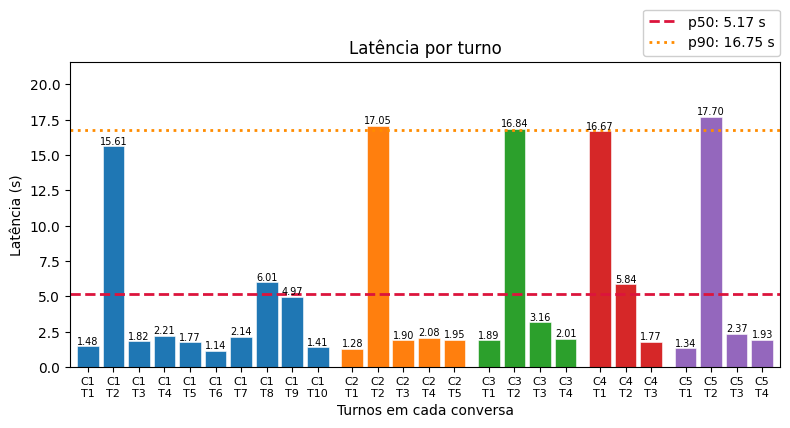

Figura salva em: /Users/vinicius.araujo/Github/genai/data/conversation_metrics_latency.png


In [26]:
fig, ax = plt.subplots(figsize=(8, 5))

gap = 0.35
x_cursor = 0.0
x_positions: list[float] = []
x_labels: list[str] = []

for i, conv in enumerate(conversations):
    lats = [float(x) for x in conv["latency"]]
    color = f"C{i}"
    for j, lat in enumerate(lats, start=1):
        ax.bar(x_cursor, lat, width=0.85, color=color, edgecolor="white", linewidth=0.4)
        ax.text(
            x_cursor,
            lat,
            f"{lat:.2f}",
            ha="center",
            va="bottom",
            fontsize=7,
        )
        x_labels.append(f"C{i + 1}\nT{j}")
        x_positions.append(x_cursor)
        x_cursor += 1.0
    x_cursor += gap

p90_latency = float(np.percentile(all_latencies, 90)) if all_latencies else 0.0

ax.axhline(mean_latency, color="crimson", linestyle="--", linewidth=2, label=f"p50: {mean_latency:.2f} s")
ax.axhline(
    p90_latency,
    color="darkorange",
    linestyle=":",
    linewidth=2,
    label=f"p90: {p90_latency:.2f} s",
)
ax.set_ylabel("Latência (s)")
ax.set_xlabel("Turnos em cada conversa")
ax.set_title("Latência por turno")
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, fontsize=8)

ymax = max(all_latencies + [mean_latency, p90_latency])
ax.set_ylim(0, ymax * 1.22)

ax.legend(
    loc="lower right",
    bbox_to_anchor=(1.0, 1.02),
    borderaxespad=0,
    framealpha=0.95,
)

ax.margins(x=0.01)
fig.tight_layout(rect=(0, 0, 1, 0.88))
fig.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figura salva em: {OUT_PNG}")

In [24]:
# Caminho da imagem no Markdown: mesmo diretório que o .md (data/)
img_name = OUT_PNG.name

md_lines = [
    "# Relatório de métricas de conversas",
    "",
    "Gerado pelo notebook `real_estate_agent/notebooks/conversation_metrics.ipynb`.",
    "",
    "## 1. Visão geral do conjunto de dados",
    "",
    f"- **Número de conversas:** {n_conversations}",
    f"- **Modelos utilizados:** {models_str}",
    f"- **Total de tokens utilizados:** {total_tokens:,}".replace(",", "."),
    f"- **Total de turnos (conversas):** {total_turns}",
    f"- **Latência média:** {mean_latency:.2f} s",
    "",
    "- **Total de mensagens por agente (`role`):**",
]

for role, count in sorted(role_counts.items(), key=lambda x: (-x[1], x[0])):
    md_lines.append(f"  - `{role}`: {count}")

md_lines.extend(
    [
        "",
        "## 2. Latência",
        "",
        f"![Latência por medição e por conversa]({img_name})",
        "",
    ]
)

OUT_MD.write_text("\n".join(md_lines), encoding="utf-8")
print(f"Markdown salvo em: {OUT_MD}")

Markdown salvo em: /Users/vinicius.araujo/Github/genai/data/conversation_metrics_report.md
